# Introduction to Decision Trees and Ensemble Methods

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn import tree
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import fetch_california_housing
import joblib
import pandas as pd
from sklearn.model_selection import GridSearchCV, KFold
import plotly.colors as colors
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestRegressor
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import tarfile
from astropy.utils.data import download_file
from astropy.table import Table
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

%matplotlib inline

In [2]:
# get data and print information about it 
from sklearn import datasets

iris = datasets.load_iris() # get data

print('The iris.data has {} samples each of which has {} features. e.g. first two data: {}'
      .format(iris.data.shape[0], iris.data.shape[1], iris.data[:2]))
print('The iris.target has labels (one of {}) for {} samples. e.g. first two labels {}'
      .format(iris.target_names, iris.target.shape[0], iris.target[:2]))

print(iris.DESCR)

The iris.data has 150 samples each of which has 4 features. e.g. first two data: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]]
The iris.target has labels (one of ['setosa' 'versicolor' 'virginica']) for 150 samples. e.g. first two labels [0 0]
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9 

In [3]:
X = iris.data[:, :2]  # we only take the first two features.
y = iris.target

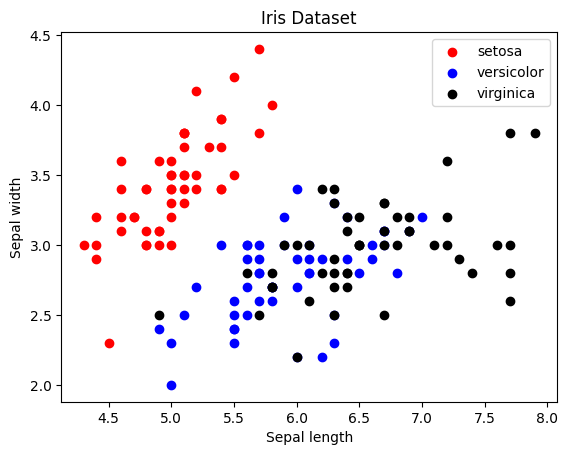

In [4]:
color_list_bold = [ '#FF0000', '#0000FF', '#000000']
labels={0:'setosa',1:'versicolor',2:'virginica'}
fig,ax=plt.subplots()
for i in range(3):
    ax.scatter(X[y==i, 0], X[y==i, 1],label=labels[i],color=color_list_bold[i])
ax.set_xlabel('Sepal length')
ax.set_ylabel('Sepal width')
ax.set_title('Iris Dataset')
ax.legend();

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, random_state = 0)

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train,y_train)

print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

Accuracy of K-NN classifier on training set: 0.96
Accuracy of K-NN classifier on test set: 0.65


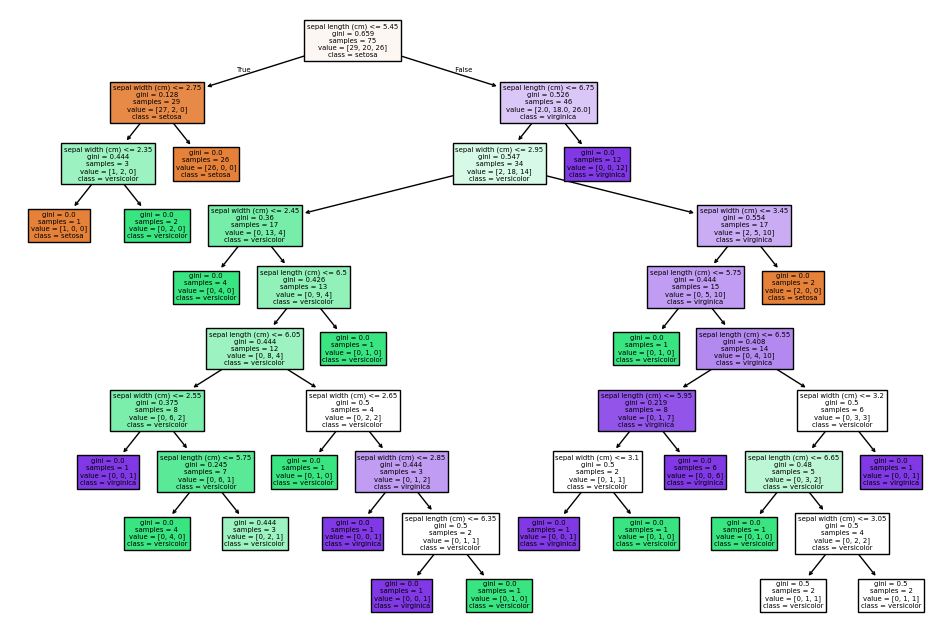

In [6]:
plt.figure(figsize=(12, 8)) 
feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
class_names=['setosa', 'versicolor', 'virginica']
tree.plot_tree(clf,
    feature_names=feature_names, 
    class_names=class_names,
    filled = True)
plt.show()

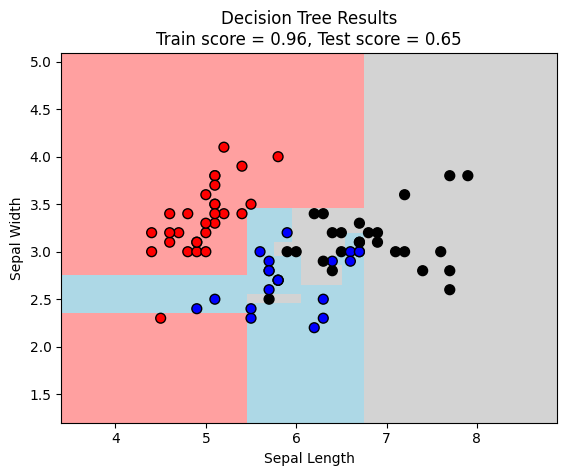

In [7]:
from plotting_dt import *

plot_two_class_dt(X_train, y_train, clf, X_test, y_test)

Above decision boundaries is what a typical decision tree model looks like for classification problems.  The above example is also a classic example of over fitting, the model is going out of its way to generalize 

# Decision Tree Hyperparameters 

There are several hyperparameters we can use to deal with decision trees being prone to over fitting.  Here are a few examples of parameters we can change in sklearn:

1. **criterion** {“gini”, “entropy”, “log_loss”}, default=”gini” (As discussed in lecture)
2. **splitter** {“best”, “random”}, default=”best” ("best" is greedy algorithm, where as "random is typically used in ensemble methods)
3. **max_depth** int, default=None: The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
4. **min_samples_split** int or float, default=2: The minimum number of samples required to split an internal node: If int, then consider min_samples_split as the minimum number.
5. **min_samples_leaf** int or float, default=1: The minimum number of samples required to be at a leaf node.

Find more example hyperparameters in [sklearns documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

## Max Depth

Accuracy of K-NN classifier on training set: 0.77
Accuracy of K-NN classifier on test set: 0.65


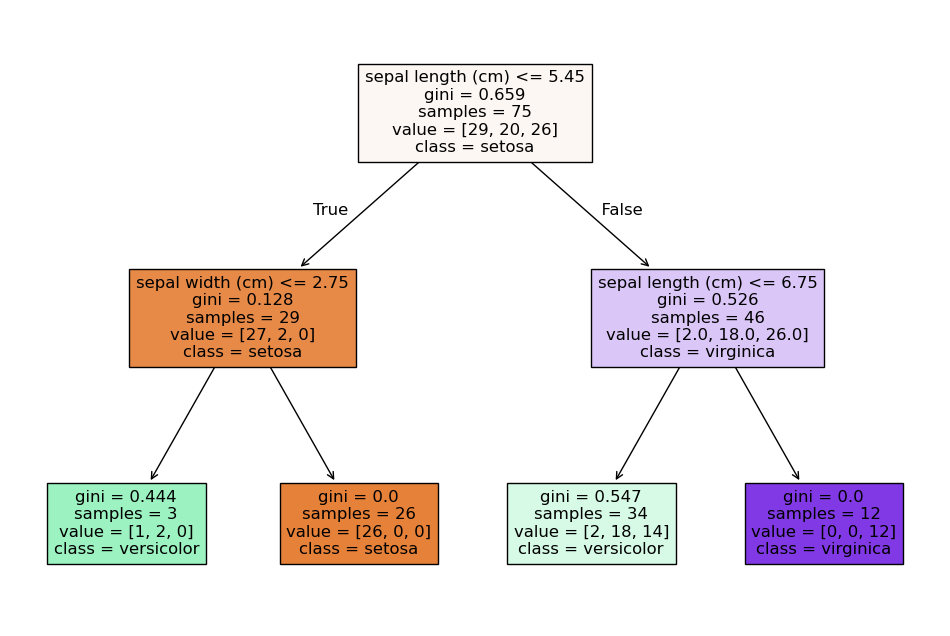

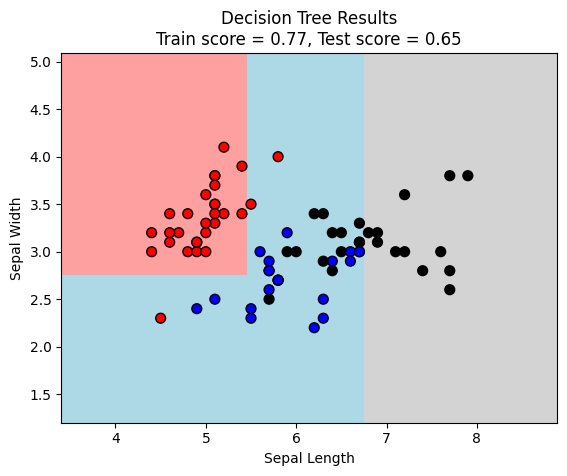

In [13]:
clf = tree.DecisionTreeClassifier(max_depth=2)
clf = clf.fit(X_train,y_train)

print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

plt.figure(figsize=(12, 8)) 
feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
class_names=['setosa', 'versicolor', 'virginica']
tree.plot_tree(clf,
    feature_names=feature_names, 
    class_names=class_names,
    filled = True)
plt.show()

plot_two_class_dt(X_train, y_train, clf, X_test, y_test)

## min_samples_leaf

Accuracy of K-NN classifier on training set: 0.89
Accuracy of K-NN classifier on test set: 0.71


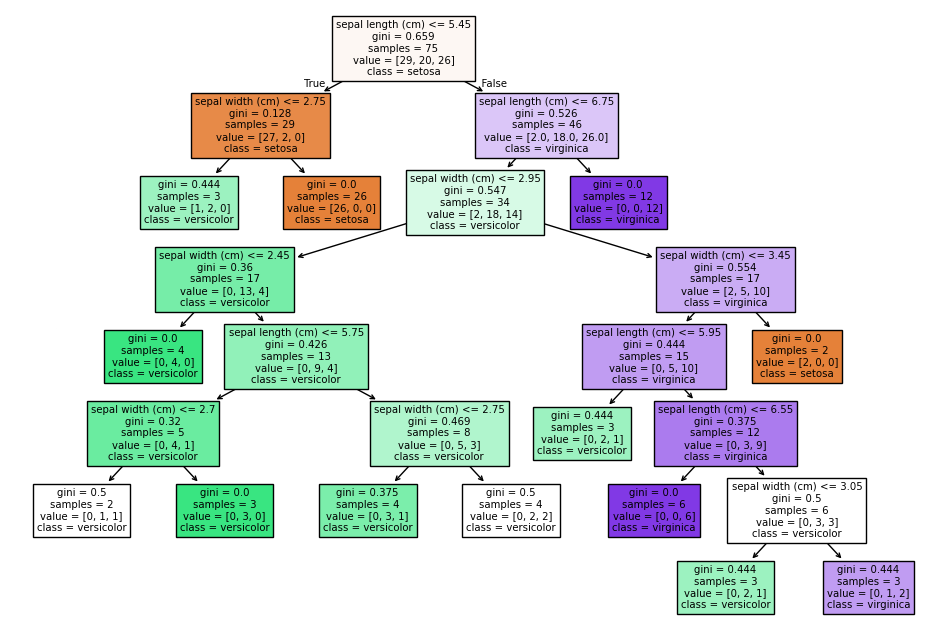

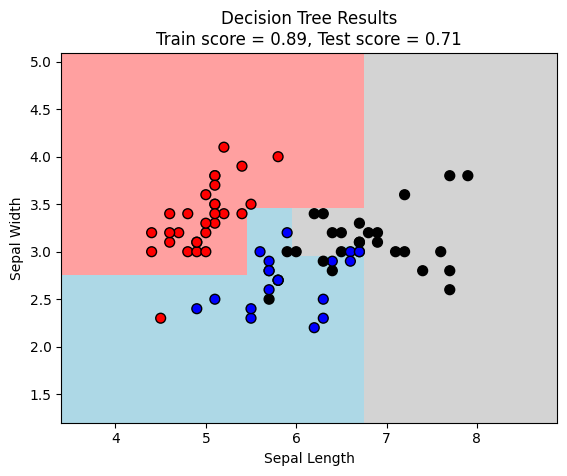

In [12]:
clf = tree.DecisionTreeClassifier(min_samples_leaf=2)
clf = clf.fit(X_train,y_train)

print('Accuracy of K-NN classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of K-NN classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

plt.figure(figsize=(12, 8)) 
feature_names=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
class_names=['setosa', 'versicolor', 'virginica']
tree.plot_tree(clf,
    feature_names=feature_names, 
    class_names=class_names,
    filled = True)
plt.show()

plot_two_class_dt(X_train, y_train, clf, X_test, y_test)